<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/NaiveBias_Winedatset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from sklearn.datasets import load_wine , load_breast_cancer , load_iris

In [ ]:
X = [load_breast_cancer().data , load_iris().data , load_wine().data]

In [ ]:
y = [load_breast_cancer().target , load_iris().target , load_wine().target]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
models = {
    'GaussianNB' : GaussianNB(var_smoothing= 1e-9),
    'KNeighborsClassifier' : KNeighborsClassifier(n_neighbors= 5),
    'DecisionTreeClassifier' : DecisionTreeClassifier(criterion = 'gini' , max_depth = 5 , random_state= 42),
    'RandomForestClassifier' : RandomForestClassifier(n_estimators= 100 , criterion = 'gini' , max_depth= None),
    'LogisticRegression' : LogisticRegression(max_iter=1000 , random_state= 42),
    'SVC' : SVC(kernel = 'rbf', C = 1 , gamma = 'scale')
}


In [ ]:
modelacc = {
    'GaussianNB' : [],
    'KNeighborsClassifier' : [],
    'DecisionTreeClassifier' : [],
    'RandomForestClassifier' : [],
    'LogisticRegression' : [],
    'SVC' : []
}

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
for i in range(len(X)):
  X_train , X_test ,y_train , y_test = train_test_split(X[i] , y[i] , test_size=0.2 , random_state=42)
  for name , model in models.items():
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test , y_pred)
    modelacc[name].append(acc)

In [ ]:
modelacc

{'GaussianNB': [0.9736842105263158, 1.0, 1.0],
 'KNeighborsClassifier': [0.956140350877193, 1.0, 0.7222222222222222],
 'DecisionTreeClassifier': [0.9473684210526315, 1.0, 0.9444444444444444],
 'RandomForestClassifier': [0.956140350877193, 1.0, 1.0],
 'LogisticRegression': [0.956140350877193, 1.0, 1.0],
 'SVC': [0.9473684210526315, 1.0, 0.8055555555555556]}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

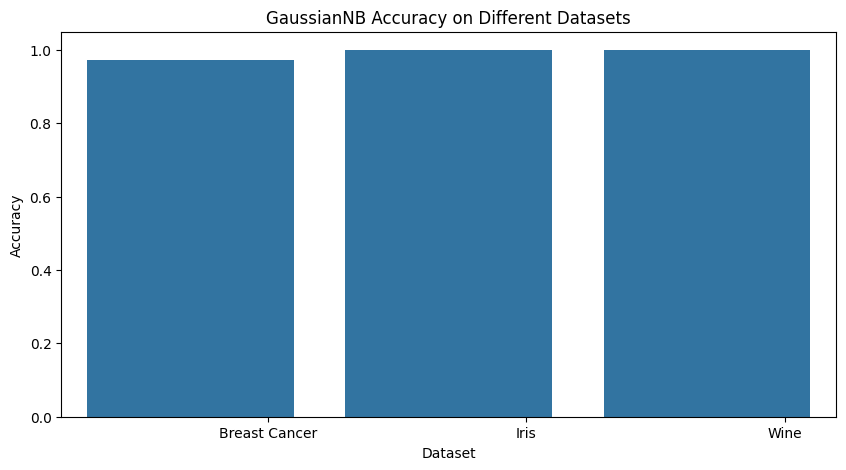

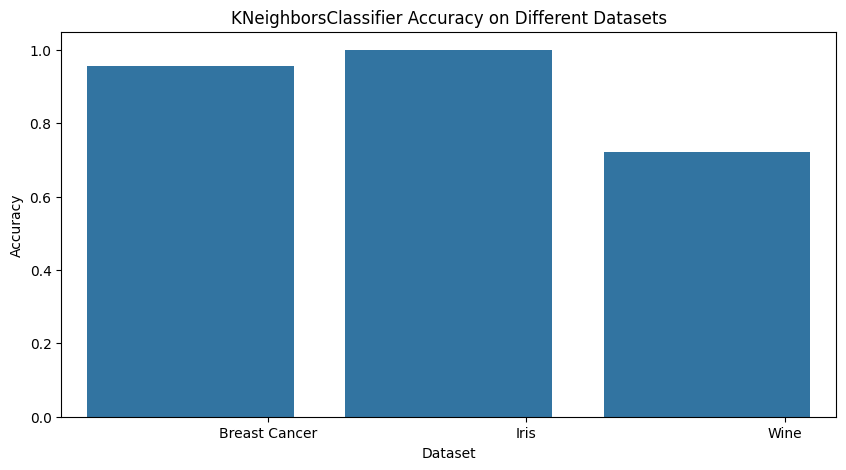

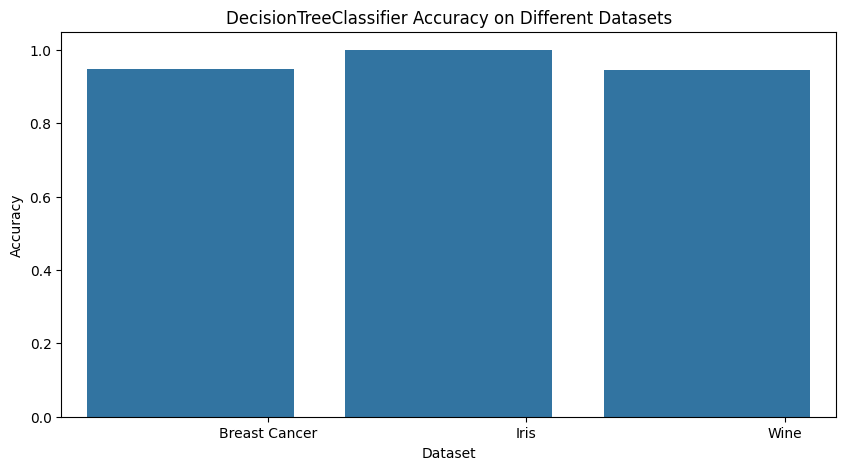

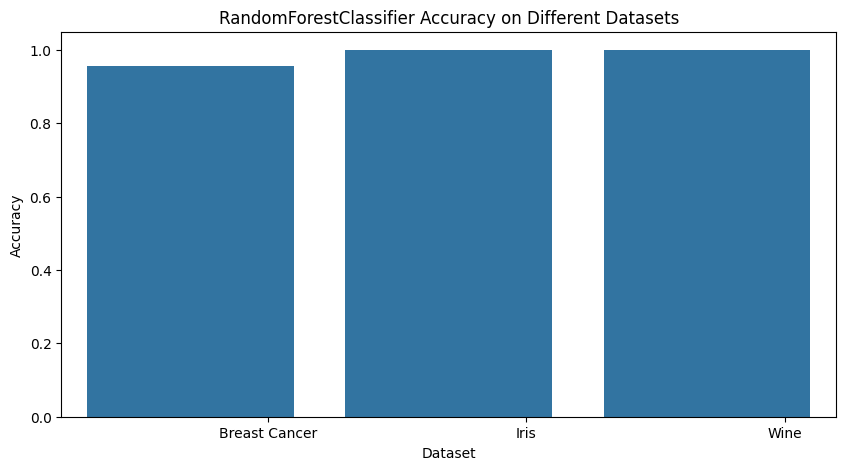

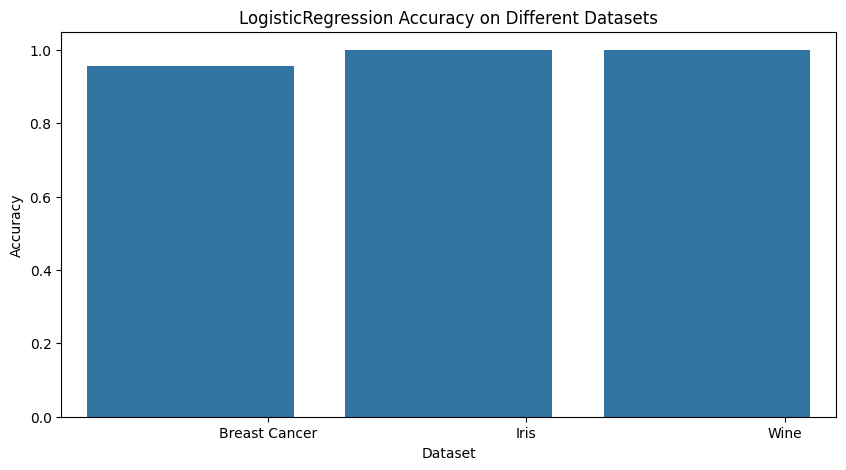

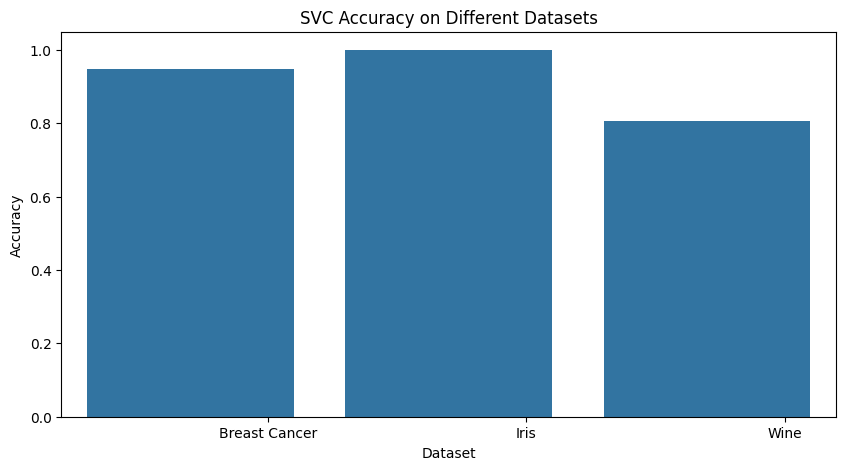

In [ ]:
datasets = ['Breast Cancer' , 'Iris' , 'Wine']
models = list(modelacc.keys())
x = np.arange(len(datasets))
width = 0.12
for i, model in enumerate(models):
  plt.figure(figsize=(10 , 5))
  sns.barplot(x=datasets, y=modelacc[model])
  plt.xticks(x + width * 2.5, datasets)
  plt.xlabel('Dataset')
  plt.ylabel('Accuracy')
  plt.title(f'{model} Accuracy on Different Datasets')
  plt.show()


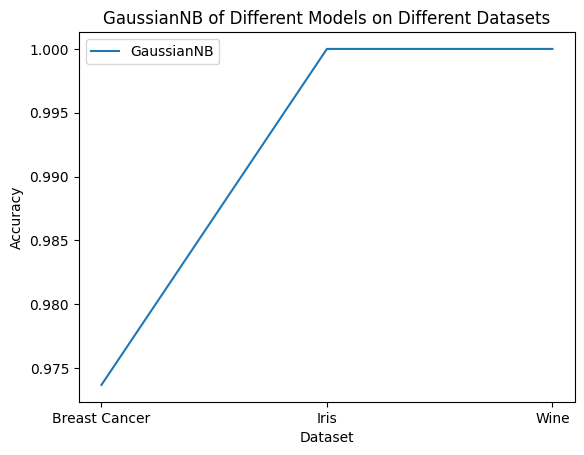

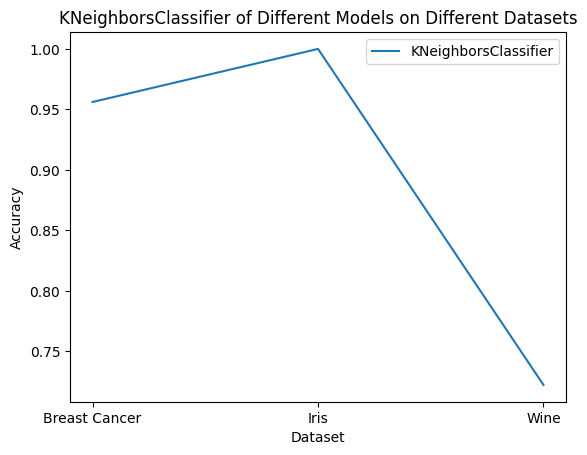

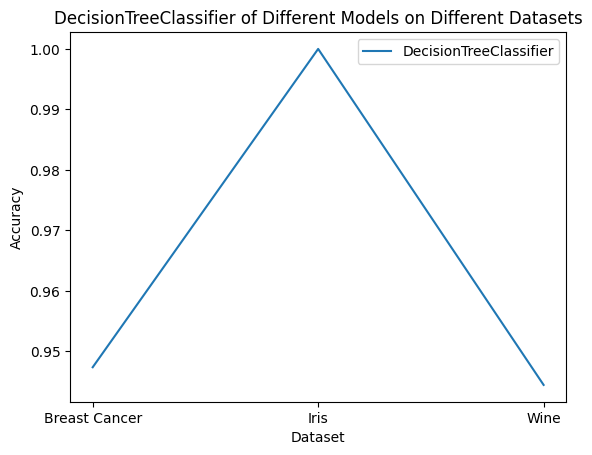

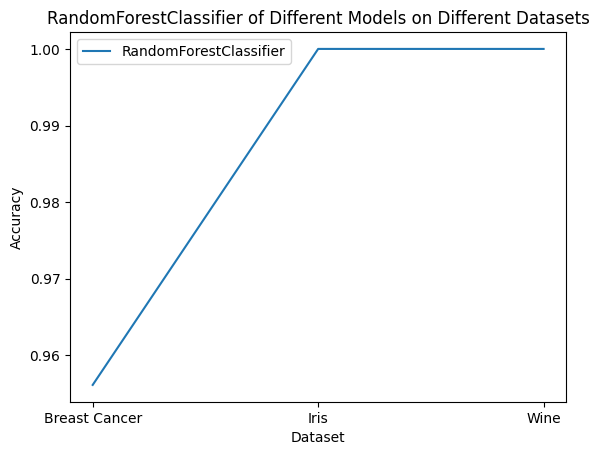

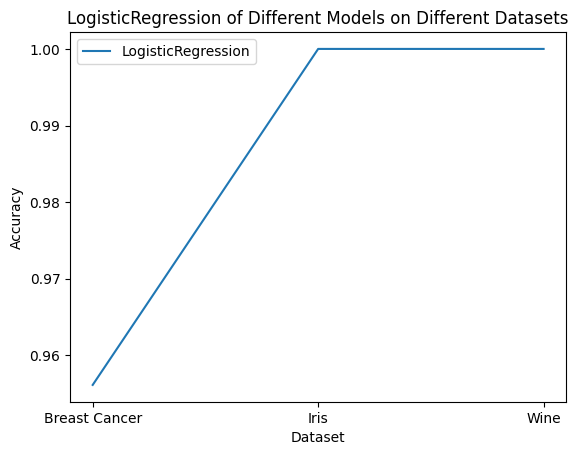

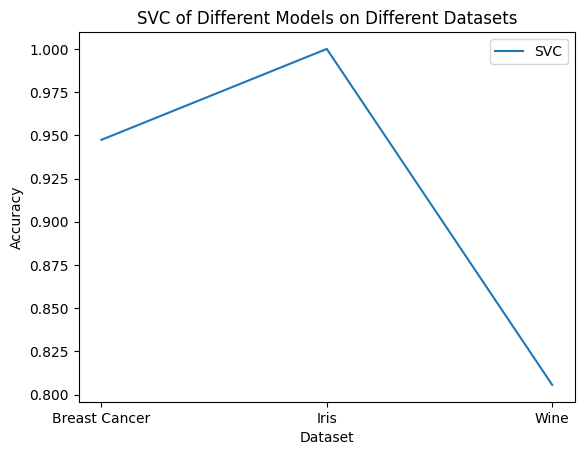

In [ ]:
for model , acc in modelacc.items():
  plt.plot(datasets , acc , label=model)
  plt.xlabel('Dataset')
  plt.ylabel('Accuracy')
  plt.title(f'{model} of Different Models on Different Datasets')
  plt.legend()
  plt.show()